#  SafeRoute Analytics – Pipeline ETL
**MSPR – Intégration de données, Sécurité & RGPD**

Ce notebook implémente le pipeline complet d'intégration de données de la startup **SafeRoute Analytics**.

---
## Datasets utilisés :
- **Accidents corporels** (data.gouv.fr) – fichier `caracteristiques-YYYY.csv`
- **Population municipale** (data.gouv.fr) – fichier `population_communes.csv`
- **Arrêts de transport** (transport.data.gouv.fr) – fichier `arrets_transport.csv`

## Architecture du pipeline :
```
COLLECTE → STAGING → CONTRÔLE QUALITÉ → TRANSFORMATION → DATAWAREHOUSE
```

## 0. Configuration & imports

In [2]:
import pandas as pd
import numpy as np
import os
import sqlite3
import hashlib
import logging
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── Configuration des dossiers du projet ──────────────────────────────────────
BASE_DIR        = os.path.dirname(os.path.abspath('__file__'))
RAW_DIR         = os.path.join(BASE_DIR, 'data', 'raw')           # données brutes sources
STAGING_DIR     = os.path.join(BASE_DIR, 'data', 'staging')       # zone staging
REJECTED_DIR    = os.path.join(BASE_DIR, 'data', 'rejected')      # lignes rejetées
DWH_DIR         = os.path.join(BASE_DIR, 'data', 'datawarehouse') # entrepôt final
LOG_DIR         = os.path.join(BASE_DIR, 'logs')                  # logs

for d in [RAW_DIR, STAGING_DIR, REJECTED_DIR, DWH_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Logger ────────────────────────────────────────────────────────────────────
log_file = os.path.join(LOG_DIR, f'pipeline_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log')
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)
logger.info('=== Démarrage du pipeline SafeRoute Analytics ===')

# ── Compteurs de qualité ───────────────────────────────────────────────────────
quality_report = {}

print(' Configuration OK – Dossiers créés')
print(f' Base : {BASE_DIR}')

2026-04-01 07:53:33,819 [INFO] === Démarrage du pipeline SafeRoute Analytics ===


 Configuration OK – Dossiers créés
 Base : c:\Users\Cylia\Downloads


---
## ÉTAPE 1 – COLLECTE

> Chargement des fichiers sources depuis les données publiques françaises.
> En production : téléchargement via API data.gouv.fr.
> En local : lecture des CSV téléchargés.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# COLLECTE – Génération de données simulées réalistes (demo sans téléchargement)
# En production, remplacer par : pd.read_csv('URL_ou_FICHIER')
# ═══════════════════════════════════════════════════════════════════════════════

np.random.seed(42)
N_ACCIDENTS = 5000

# Codes INSEE de communes françaises (échantillon réaliste)
codes_insee = [
    '75056', '69123', '13055', '31555', '59350',
    '06088', '67482', '44109', '34172', '35238',
    '76351', '45234', '57463', '38185', '21231',
    '29019', '80021', '62041', '51108', '54395'
]

# ── Dataset 1 : Accidents corporels ──────────────────────────────────────────
accidents_raw = pd.DataFrame({
    'Num_Acc'      : [f'ACC{str(i).zfill(6)}' for i in range(1, N_ACCIDENTS+1)],
    'an'           : np.random.choice([2019, 2020, 2021, 2022, 2023], N_ACCIDENTS),
    'mois'         : np.random.randint(1, 13, N_ACCIDENTS),
    'jour'         : np.random.randint(1, 29, N_ACCIDENTS),
    'hrmn'         : [f'{h:02d}{m:02d}' for h, m in zip(
                         np.random.randint(0, 24, N_ACCIDENTS),
                         np.random.choice([0, 15, 30, 45], N_ACCIDENTS))],
    'lum'          : np.random.choice([1, 2, 3, 4, 5], N_ACCIDENTS),     # luminosité
    'dep'          : np.random.choice(['75','69','13','31','59','06','67','44','34','35',
                                        '76','45','57','38','21','29','80','62','51','54',
                                        np.nan], N_ACCIDENTS, p=[0.05]*20+[0.0]),
    'com'          : np.random.choice(codes_insee + [None]*3, N_ACCIDENTS),
    'agg'          : np.random.choice([1, 2], N_ACCIDENTS),              # en/hors agglomération
    'int'          : np.random.choice([1,2,3,4,5,6,7,9], N_ACCIDENTS),  # type intersection
    'atm'          : np.random.choice([1,2,3,4,5,6,7,8,9], N_ACCIDENTS),# conditions atmo
    'col'          : np.random.choice([1,2,3,4,5,6,7], N_ACCIDENTS),    # type collision
    'lat'          : np.where(np.random.rand(N_ACCIDENTS) < 0.05, np.nan,
                              np.random.uniform(41.3, 51.1, N_ACCIDENTS)),
    'long'         : np.where(np.random.rand(N_ACCIDENTS) < 0.05, np.nan,
                              np.random.uniform(-5.1, 9.6, N_ACCIDENTS)),
    'grav'         : np.random.choice([1, 2, 3, 4], N_ACCIDENTS,        # gravité
                                       p=[0.35, 0.45, 0.12, 0.08]),
    'nb_victimes'  : np.random.randint(1, 5, N_ACCIDENTS),
})

# Introduire des anomalies volontaires pour tester le contrôle qualité
accidents_raw.loc[10:15, 'lat'] = 999.0          # coordonnées invalides
accidents_raw.loc[20:22, 'Num_Acc'] = 'ACC000001' # doublons
accidents_raw.loc[30, 'mois'] = 13               # mois invalide
accidents_raw.loc[35, 'nb_victimes'] = -1        # valeur négative
accidents_raw.loc[40:45, 'dep'] = np.nan         # département manquant

# ── Dataset 2 : Population municipale ────────────────────────────────────────
population_raw = pd.DataFrame({
    'code_commune' : codes_insee,
    'nom_commune'  : ['Paris','Lyon','Marseille','Toulouse','Lille',
                      'Nice','Strasbourg','Nantes','Montpellier','Rennes',
                      'Rouen','Orléans','Metz','Grenoble','Dijon',
                      'Brest','Amiens','Lens','Reims','Nancy'],
    'departement'  : ['75','69','13','31','59','06','67','44','34','35',
                      '76','45','57','38','21','29','80','62','51','54'],
    'region'       : ['IDF','ARA','PACA','OCC','HDF','PACA','GES','PDL','OCC','BRE',
                      'NOR','CVL','GES','ARA','BFC','BRE','HDF','HDF','GES','GES'],
    'population'   : [2161000,515695,861635,471941,232741,
                      342669,280966,309346,285121,216815,
                      110169,114644,117456,158180,155975,
                      139849,134706,32559,183042,104885],
    'superficie_km2': np.random.uniform(5, 500, 20).round(2),
})

# ── Dataset 3 : Arrêts de transport ──────────────────────────────────────────
n_arrets = 2000
transport_raw = pd.DataFrame({
    'stop_id'      : [f'STOP{str(i).zfill(5)}' for i in range(1, n_arrets+1)],
    'stop_name'    : [f'Arrêt_{i}' for i in range(1, n_arrets+1)],
    'stop_lat'     : np.where(np.random.rand(n_arrets) < 0.03, np.nan,
                              np.random.uniform(41.3, 51.1, n_arrets)),
    'stop_lon'     : np.where(np.random.rand(n_arrets) < 0.03, np.nan,
                              np.random.uniform(-5.1, 9.6, n_arrets)),
    'commune_code' : np.random.choice(codes_insee, n_arrets),
    'type_transport': np.random.choice(['bus','tram','metro','train','car'], n_arrets,
                                        p=[0.5, 0.15, 0.1, 0.15, 0.1]),
})

logger.info(f'COLLECTE – Accidents : {len(accidents_raw)} lignes')
logger.info(f'COLLECTE – Population : {len(population_raw)} lignes')
logger.info(f'COLLECTE – Transport : {len(transport_raw)} lignes')

print(' COLLECTE terminée')
print(f'   ├── Accidents  : {len(accidents_raw):,} lignes')
print(f'   ├── Population : {len(population_raw):,} communes')
print(f'   └── Transport  : {len(transport_raw):,} arrêts')
accidents_raw.head(3)

2026-04-01 07:53:33,907 [INFO] COLLECTE – Accidents : 5000 lignes
2026-04-01 07:53:33,908 [INFO] COLLECTE – Population : 20 lignes
2026-04-01 07:53:33,909 [INFO] COLLECTE – Transport : 2000 lignes


 COLLECTE terminée
   ├── Accidents  : 5,000 lignes
   ├── Population : 20 communes
   └── Transport  : 2,000 arrêts


,Num_Acc,an,mois,jour,hrmn,lum,dep,com,agg,int,atm,col,lat,long,grav,nb_victimes
0,ACC000001,2022,7,23,1100,5,34,38185,2,2,9,7,44.468738,-1.980238,1,1
1,ACC000002,2023,10,20,1800,5,51,38185,1,4,7,4,43.480041,0.032210,4,4
2,ACC000003,2021,7,6,1500,4,51,54395,2,9,7,6,46.921146,-2.056415,1,2


---
## ÉTAPE 2 – STAGING

> Chargement brut avec traçabilité : horodatage d'ingestion, source, hash de ligne.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# STAGING – Zone tampon avec métadonnées de traçabilité
# ═══════════════════════════════════════════════════════════════════════════════
def add_staging_metadata(df, source_name):
    """Ajoute les colonnes de traçabilité à chaque ligne du staging."""
    df = df.copy()
    df['_src_file']      = source_name
    df['_ingested_at']   = datetime.now().isoformat()
    df['_row_id']        = range(1, len(df) + 1)
    df['_row_hash']      = df.apply(
        lambda row: hashlib.md5(
            str(row.drop(['_src_file','_ingested_at','_row_id']).values).encode()
        ).hexdigest(), axis=1
    )
    df['_status']        = 'STAGING'   # sera mis à jour : OK / REJET
    return df

# Chargement en staging
stg_accidents  = add_staging_metadata(accidents_raw,  'accidents_corporels_2023.csv')
stg_population = add_staging_metadata(population_raw, 'population_municipale.csv')
stg_transport  = add_staging_metadata(transport_raw,  'arrets_transport.csv')

# Sauvegarde staging sur disque (parquet = efficace)
stg_accidents.to_csv(os.path.join(STAGING_DIR, 'stg_accidents.csv'), index=False)
stg_population.to_csv(os.path.join(STAGING_DIR, 'stg_population.csv'), index=False)
stg_transport.to_csv(os.path.join(STAGING_DIR, 'stg_transport.csv'), index=False)

logger.info('STAGING – Données chargées en zone staging')
print(' STAGING terminé')
print(f'   ├── stg_accidents.parquet  → {len(stg_accidents):,} lignes')
print(f'   ├── stg_population.parquet → {len(stg_population):,} lignes')
print(f'   └── stg_transport.parquet  → {len(stg_transport):,} lignes')
print()
print('Exemple de métadonnées de traçabilité :')
stg_accidents[['Num_Acc','_src_file','_ingested_at','_row_hash','_status']].head(3)

2026-04-01 07:53:35,181 [INFO] STAGING – Données chargées en zone staging


 STAGING terminé
   ├── stg_accidents.parquet  → 5,000 lignes
   ├── stg_population.parquet → 20 lignes
   └── stg_transport.parquet  → 2,000 lignes

Exemple de métadonnées de traçabilité :


,Num_Acc,_src_file,_ingested_at,_row_hash,_status
0,ACC000001,accidents_corporels_2023.csv,2026-04-01T07:53:33.950146,f63460378ddea18d0b72a0d0dd001c46,STAGING
1,ACC000002,accidents_corporels_2023.csv,2026-04-01T07:53:33.950146,12c9a0d0495615ed9c05c6b227a0883e,STAGING
2,ACC000003,accidents_corporels_2023.csv,2026-04-01T07:53:33.950146,bfe3dc889ef2c270575da49a98254f8f,STAGING


---
## ÉTAPE 3 – CONTRÔLE QUALITÉ

> Détection de valeurs manquantes, doublons, formats invalides, valeurs aberrantes.
> Les lignes invalides sont isolées dans la zone `rejected/` avec motif de rejet.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONTRÔLE QUALITÉ – Accidents
# ═══════════════════════════════════════════════════════════════════════════════

df = stg_accidents.copy()
rejected_rows = []
initial_count = len(df)

print(f"{'─' * 60}")
print('CONTRÔLE QUALITÉ – Accidents corporels')
print(f"{'─' * 60}")
print(f'Lignes initiales : {initial_count:,}')
print()

# ── 1. Détection des doublons ─────────────────────────────────────────────────
doublons = df[df.duplicated(subset=['Num_Acc'], keep='first')].copy()
doublons['_reject_reason'] = 'DOUBLON_NUM_ACC'
rejected_rows.append(doublons)
df = df[~df.duplicated(subset=['Num_Acc'], keep='first')]
print(f'[DOUBLONS]     {len(doublons)} lignes rejetées (Num_Acc dupliqué)')

# ── 2. Valeurs manquantes sur colonnes clés ───────────────────────────────────
cols_obligatoires = ['Num_Acc', 'an', 'mois', 'jour', 'grav']
mask_manquants = df[cols_obligatoires].isnull().any(axis=1)
manquants = df[mask_manquants].copy()
manquants['_reject_reason'] = 'CHAMP_OBLIGATOIRE_MANQUANT'
rejected_rows.append(manquants)
df = df[~mask_manquants]
print(f'[MANQUANTS]    {len(manquants)} lignes rejetées (champs obligatoires vides)')

# ── 3. Mois invalide ─────────────────────────────────────────────────────────
mask_mois = ~df['mois'].between(1, 12)
mois_invalides = df[mask_mois].copy()
mois_invalides['_reject_reason'] = 'MOIS_INVALIDE'
rejected_rows.append(mois_invalides)
df = df[~mask_mois]
print(f'[FORMAT]       {len(mois_invalides)} lignes rejetées (mois hors [1-12])')

# ── 4. Coordonnées GPS hors bornes France ─────────────────────────────────────
mask_gps = df['lat'].notna() & (~df['lat'].between(41.3, 51.2))
gps_invalides = df[mask_gps].copy()
gps_invalides['_reject_reason'] = 'GPS_HORS_FRANCE'
rejected_rows.append(gps_invalides)
df = df[~mask_gps]
print(f'[GPS]          {len(gps_invalides)} lignes rejetées (coordonnées hors France)')

# ── 5. Nombre de victimes invalide ────────────────────────────────────────────
mask_victimes = df['nb_victimes'] <= 0
victimes_invalides = df[mask_victimes].copy()
victimes_invalides['_reject_reason'] = 'NB_VICTIMES_INVALIDE'
rejected_rows.append(victimes_invalides)
df = df[~mask_victimes]
print(f'[VALEUR]       {len(victimes_invalides)} lignes rejetées (nb_victimes <= 0)')

# ── 6. Taux de valeurs manquantes par colonne ─────────────────────────────────
print()
print('Taux de valeurs manquantes (sur données retenues) :')
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
for col, pct in missing_pct[missing_pct > 0].items():
    flag = ' ' if pct > 10 else '  '
    print(f'  {flag}{col:<20} : {pct:.1f}%')

# ── Sauvegarde des rejets ─────────────────────────────────────────────────────
if rejected_rows:
    df_rejected = pd.concat(rejected_rows, ignore_index=True)
    df_rejected['_rejected_at'] = datetime.now().isoformat()
    df_rejected.to_csv(os.path.join(REJECTED_DIR, 'rejected_accidents.csv'), index=False)

# Mise à jour statut staging
df['_status'] = 'VALIDE'

# Rapport qualité
total_rejetes = initial_count - len(df)
taux_qualite = (len(df) / initial_count * 100)
quality_report['accidents'] = {
    'initial': initial_count, 'valides': len(df),
    'rejetes': total_rejetes, 'taux_qualite': round(taux_qualite, 2)
}

print()
print(f"{'─' * 60}")
print(f' Lignes valides  : {len(df):,} ({taux_qualite:.1f}%)')
print(f' Lignes rejetées : {total_rejetes:,} ({100-taux_qualite:.1f}%)')
print(f'   → Fichier rejets : rejected/rejected_accidents.csv')

accidents_clean = df
logger.info(f'QC ACCIDENTS – {len(df)} valides / {total_rejetes} rejetés')

2026-04-01 07:53:35,271 [INFO] QC ACCIDENTS – 4989 valides / 11 rejetés


────────────────────────────────────────────────────────────
CONTRÔLE QUALITÉ – Accidents corporels
────────────────────────────────────────────────────────────
Lignes initiales : 5,000

[DOUBLONS]     3 lignes rejetées (Num_Acc dupliqué)
[MANQUANTS]    0 lignes rejetées (champs obligatoires vides)
[FORMAT]       1 lignes rejetées (mois hors [1-12])
[GPS]          6 lignes rejetées (coordonnées hors France)
[VALEUR]       1 lignes rejetées (nb_victimes <= 0)

Taux de valeurs manquantes (sur données retenues) :
    dep                  : 0.1%
   com                  : 13.7%
    lat                  : 4.5%
    long                 : 5.2%

────────────────────────────────────────────────────────────
 Lignes valides  : 4,989 (99.8%)
 Lignes rejetées : 11 (0.2%)
   → Fichier rejets : rejected/rejected_accidents.csv


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONTRÔLE QUALITÉ – Population & Transport
# ═══════════════════════════════════════════════════════════════════════════════

# ── Population ────────────────────────────────────────────────────────────────
df_pop = stg_population.copy()
rej_pop = []

# Code commune invalide (doit être 5 chiffres)
mask_code = ~df_pop['code_commune'].str.match(r'^\d{5}$', na=False)
rej_pop_code = df_pop[mask_code].copy()
rej_pop_code['_reject_reason'] = 'CODE_COMMUNE_INVALIDE'
rej_pop.append(rej_pop_code)
df_pop = df_pop[~mask_code]

# Population négative ou nulle
mask_pop = df_pop['population'] <= 0
rej_pop_neg = df_pop[mask_pop].copy()
rej_pop_neg['_reject_reason'] = 'POPULATION_INVALIDE'
rej_pop.append(rej_pop_neg)
df_pop = df_pop[~mask_pop]

df_pop['_status'] = 'VALIDE'
quality_report['population'] = {'initial': len(stg_population), 'valides': len(df_pop)}
print(f' Population  : {len(df_pop)} communes valides')

# ── Transport ────────────────────────────────────────────────────────────────
df_tr = stg_transport.copy()
rej_tr = []

# Coordonnées manquantes
mask_coord = df_tr['stop_lat'].isna() | df_tr['stop_lon'].isna()
rej_tr_coord = df_tr[mask_coord].copy()
rej_tr_coord['_reject_reason'] = 'COORDONNEES_MANQUANTES'
rej_tr.append(rej_tr_coord)
df_tr = df_tr[~mask_coord]

# Doublons stop_id
rej_tr_dup = df_tr[df_tr.duplicated(subset=['stop_id'], keep='first')].copy()
rej_tr_dup['_reject_reason'] = 'DOUBLON_STOP_ID'
rej_tr.append(rej_tr_dup)
df_tr = df_tr[~df_tr.duplicated(subset=['stop_id'], keep='first')]

if rej_tr:
    pd.concat(rej_tr).to_csv(os.path.join(REJECTED_DIR, 'rejected_transport.csv'), index=False)

df_tr['_status'] = 'VALIDE'
quality_report['transport'] = {'initial': len(stg_transport), 'valides': len(df_tr)}
print(f' Transport   : {len(df_tr)} arrêts valides')

population_clean = df_pop
transport_clean  = df_tr

logger.info('CONTRÔLE QUALITÉ terminé sur les 3 datasets')

2026-04-01 07:53:35,311 [INFO] CONTRÔLE QUALITÉ terminé sur les 3 datasets


 Population  : 20 communes valides
 Transport   : 1879 arrêts valides


---
## ÉTAPE 4 – TRANSFORMATION

> Nettoyage, harmonisation, jointures, enrichissements, calcul d'indicateurs métier.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRANSFORMATION 1 – Nettoyage & harmonisation des accidents
# ═══════════════════════════════════════════════════════════════════════════════

df_acc = accidents_clean.copy()

# ── Standardisation des codes départements ─────────────────────────────────
df_acc['dep'] = df_acc['dep'].astype(str).str.zfill(2).str.strip()
df_acc['dep'] = df_acc['dep'].replace('nan', np.nan)

# ── Harmonisation du code commune ─────────────────────────────────────────
df_acc['com'] = df_acc['com'].astype(str).str.strip()
df_acc['com'] = df_acc['com'].replace('None', np.nan)

# ── Création de la date ────────────────────────────────────────────────────
df_acc['date_accident'] = pd.to_datetime(
    df_acc[['an','mois','jour']].rename(columns={'an':'year','mois':'month','jour':'day'}),
    errors='coerce'
)

# ── Extraction de l'heure ──────────────────────────────────────────────────
df_acc['heure'] = df_acc['hrmn'].astype(str).str[:2].astype(float)
df_acc['heure'] = df_acc['heure'].clip(0, 23)

# ── Catégorie de gravité ───────────────────────────────────────────────────
gravite_map = {1: 'Indemne', 2: 'Blessé léger', 3: 'Blessé hospitalisé', 4: 'Tué'}
df_acc['gravite_label'] = df_acc['grav'].map(gravite_map)
df_acc['est_mortel']    = df_acc['grav'] == 4

# ── Tranche horaire ────────────────────────────────────────────────────────
bins   = [0, 6, 9, 12, 17, 20, 24]
labels = ['Nuit (0-6h)', 'Matin (6-9h)', 'Journée (9-12h)',
          'Après-midi (12-17h)', 'Soir (17-20h)', 'Soirée (20-24h)']
df_acc['tranche_horaire'] = pd.cut(df_acc['heure'], bins=bins, labels=labels, right=False)

# ── Conditions météo simplifiées ───────────────────────────────────────────
atm_map = {1:'Normale', 2:'Pluie légère', 3:'Pluie forte', 4:'Neige/grêle',
           5:'Brouillard', 6:'Vent fort', 7:'Éblouissante', 8:'Couverture nuageuse', 9:'Autre'}
df_acc['conditions_meteo'] = df_acc['atm'].map(atm_map)

# ── Type de zone ───────────────────────────────────────────────────────────
df_acc['type_zone'] = df_acc['agg'].map({1: 'Hors agglomération', 2: 'En agglomération'})

print(' Transformation accidents :')
print(f'   ├── date_accident créée')
print(f'   ├── gravite_label mappé')
print(f'   ├── tranche_horaire calculée')
print(f'   └── conditions_meteo enrichies')
df_acc[['Num_Acc','date_accident','gravite_label','tranche_horaire','conditions_meteo','type_zone']].head(5)

 Transformation accidents :
   ├── date_accident créée
   ├── gravite_label mappé
   ├── tranche_horaire calculée
   └── conditions_meteo enrichies


,Num_Acc,date_accident,gravite_label,tranche_horaire,conditions_meteo,type_zone
0,ACC000001,2022-07-23,Indemne,Journée (9-12h),Autre,En agglomération
1,ACC000002,2023-10-20,Tué,Soir (17-20h),Éblouissante,Hors agglomération
2,ACC000003,2021-07-06,Indemne,Après-midi (12-17h),Éblouissante,En agglomération
3,ACC000004,2023-04-24,Blessé léger,Soirée (20-24h),Normale,En agglomération
4,ACC000005,2023-12-22,Blessé léger,Soirée (20-24h),Couverture nuageuse,En agglomération


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRANSFORMATION 2 – Jointures & enrichissements
# ═══════════════════════════════════════════════════════════════════════════════

# ── Jointure accidents × population (via code_commune) ─────────────────────
df_acc_pop = df_acc.merge(
    population_clean[['code_commune','nom_commune','departement','region','population','superficie_km2']],
    left_on='com', right_on='code_commune',
    how='left'
)
print(f'Jointure accidents × population : {len(df_acc_pop):,} lignes ({df_acc_pop["nom_commune"].notna().sum():,} matchs)')

# ── Nombre d'arrêts de transport par commune ─────────────────────────────
arrets_par_commune = (
    transport_clean.groupby('commune_code')
    .agg(nb_arrets_transport=('stop_id','count'),
         types_transport=('type_transport', lambda x: ','.join(sorted(x.unique()))))
    .reset_index()
)

# ── Jointure avec transport ────────────────────────────────────────────────
df_enrichi = df_acc_pop.merge(
    arrets_par_commune,
    left_on='com', right_on='commune_code',
    how='left'
)
df_enrichi['nb_arrets_transport'] = df_enrichi['nb_arrets_transport'].fillna(0)
df_enrichi['zone_mal_desservie']  = df_enrichi['nb_arrets_transport'] < 10

print(f'Jointure avec transport : {len(df_enrichi):,} lignes')
print(f'   → Zones mal desservies : {df_enrichi["zone_mal_desservie"].sum()} accidents')
print()

# ── Densité de population ────────────────────────────────────────────────
df_enrichi['densite_pop'] = (
    df_enrichi['population'] / df_enrichi['superficie_km2']
).round(2)

print(' Enrichissement terminé')
df_enrichi[['Num_Acc','nom_commune','population','nb_arrets_transport','gravite_label']].head(5)

Jointure accidents × population : 4,989 lignes (4,306 matchs)
Jointure avec transport : 4,989 lignes
   → Zones mal desservies : 683 accidents

 Enrichissement terminé


,Num_Acc,nom_commune,population,nb_arrets_transport,gravite_label
0,ACC000001,Grenoble,158180.0,97.0,Indemne
1,ACC000002,Grenoble,158180.0,97.0,Tué
2,ACC000003,Nancy,104885.0,86.0,Indemne
3,ACC000004,NaN,NaN,0.0,Blessé léger
4,ACC000005,Amiens,134706.0,94.0,Blessé léger


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRANSFORMATION 3 – Calcul des indicateurs métier (agrégats)
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1. Indicateurs par commune ────────────────────────────────────────────
agg_commune = df_enrichi.groupby(
    ['com','nom_commune','region','departement','population','superficie_km2',
     'nb_arrets_transport','densite_pop']
).agg(
    nb_accidents         = ('Num_Acc', 'count'),
    nb_accidents_mortels = ('est_mortel', 'sum'),
    nb_victimes_total    = ('nb_victimes', 'sum'),
    nb_blesses_hospit    = ('grav', lambda x: (x == 3).sum()),
).reset_index()

# Taux pour 100 000 habitants
agg_commune['taux_accidents_100k']  = (
    agg_commune['nb_accidents'] / agg_commune['population'] * 100_000
).round(2)
agg_commune['taux_mortalite_100k']  = (
    agg_commune['nb_accidents_mortels'] / agg_commune['population'] * 100_000
).round(2)

# Score de risque composite (0-100)
def min_max(series):
    r = series.max() - series.min()
    return (series - series.min()) / r if r > 0 else series * 0

agg_commune['score_risque'] = (
    min_max(agg_commune['taux_accidents_100k'])  * 0.5 +
    min_max(agg_commune['taux_mortalite_100k'])  * 0.3 +
    min_max(agg_commune['nb_victimes_total'])     * 0.2
).mul(100).round(1)

# Niveau de risque
def classe_risque(score):
    if score >= 70: return 'CRITIQUE'
    elif score >= 40: return 'ÉLEVÉ'
    elif score >= 20: return 'MODÉRÉ'
    else: return 'FAIBLE'

agg_commune['classe_risque'] = agg_commune['score_risque'].apply(classe_risque)

print(' Indicateurs par commune calculés')
print(f'   ├── {len(agg_commune)} communes dans le périmètre')
print(f"   ├── Zones CRITIQUES  : {(agg_commune['classe_risque']=='CRITIQUE').sum()}")
print(f"   ├── Zones ÉLEVÉES    : {(agg_commune['classe_risque']=='ÉLEVÉ').sum()}")
print(f"   └── Top commune accidentogène : {agg_commune.nlargest(1,'nb_accidents')['nom_commune'].values[0]}")

# ── 2. Indicateurs par tranche horaire ───────────────────────────────────
agg_horaire = df_enrichi.groupby('tranche_horaire').agg(
    nb_accidents         = ('Num_Acc', 'count'),
    nb_mortels           = ('est_mortel', 'sum'),
    pct_mortel           = ('est_mortel', lambda x: round(x.mean()*100, 2))
).reset_index()

# ── 3. Indicateurs par conditions météo ──────────────────────────────────
agg_meteo = df_enrichi.groupby('conditions_meteo').agg(
    nb_accidents = ('Num_Acc', 'count'),
    nb_mortels   = ('est_mortel', 'sum'),
).reset_index().sort_values('nb_accidents', ascending=False)

# ── 4. Indicateurs par année ─────────────────────────────────────────────
agg_annee = df_enrichi.groupby('an').agg(
    nb_accidents  = ('Num_Acc', 'count'),
    nb_mortels    = ('est_mortel', 'sum'),
    nb_victimes   = ('nb_victimes', 'sum')
).reset_index()

print()
print('Accidents par tranche horaire :')
print(agg_horaire.to_string(index=False))

 Indicateurs par commune calculés
   ├── 20 communes dans le périmètre
   ├── Zones CRITIQUES  : 1
   ├── Zones ÉLEVÉES    : 1
   └── Top commune accidentogène : Nancy

Accidents par tranche horaire :
    tranche_horaire  nb_accidents  nb_mortels  pct_mortel
        Nuit (0-6h)          1204         103        8.55
       Matin (6-9h)           632          56        8.86
    Journée (9-12h)           574          44        7.67
Après-midi (12-17h)          1064          92        8.65
      Soir (17-20h)           665          47        7.07
    Soirée (20-24h)           850          60        7.06


---
## ÉTAPE 5 – DATAWAREHOUSE

> Stockage final structuré en SQLite (simule un entrepôt de données).
> Tables prêtes pour la restitution et l'analyse.

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATAWAREHOUSE – Chargement des tables finales dans SQLite
# ═══════════════════════════════════════════════════════════════════════════════

DWH_PATH = os.path.join(DWH_DIR, 'saferoute_dwh.db')
conn = sqlite3.connect(DWH_PATH)

# ── Table FACT : accidents détaillés ─────────────────────────────────────
cols_fact = [
    'Num_Acc','an','date_accident','heure','tranche_horaire',
    'com','nom_commune','departement','region',
    'grav','gravite_label','est_mortel','nb_victimes',
    'conditions_meteo','type_zone','lat','long',
    'nb_arrets_transport','zone_mal_desservie','densite_pop'
]
cols_fact_ok = [c for c in cols_fact if c in df_enrichi.columns]
fact_accidents = df_enrichi[cols_fact_ok].copy()
fact_accidents['date_accident'] = fact_accidents['date_accident'].astype(str)
fact_accidents['tranche_horaire'] = fact_accidents['tranche_horaire'].astype(str)
fact_accidents.to_sql('fact_accidents', conn, if_exists='replace', index=False)
print(f' fact_accidents      : {len(fact_accidents):,} lignes')

# ── Table DIM : communes ──────────────────────────────────────────────────
dim_commune = population_clean[[
    'code_commune','nom_commune','departement','region','population','superficie_km2'
]].copy()
dim_commune.to_sql('dim_commune', conn, if_exists='replace', index=False)
print(f' dim_commune         : {len(dim_commune):,} communes')

# ── Table DIM : transport ─────────────────────────────────────────────────
dim_transport = arrets_par_commune.copy()
dim_transport.to_sql('dim_transport', conn, if_exists='replace', index=False)
print(f' dim_transport       : {len(dim_transport):,} communes avec arrêts')

# ── Table AGG : risque par commune ────────────────────────────────────────
agg_commune['classe_risque'] = agg_commune['classe_risque'].astype(str)
agg_commune.to_sql('agg_risque_commune', conn, if_exists='replace', index=False)
print(f' agg_risque_commune  : {len(agg_commune):,} lignes')

# ── Table AGG : horaire ───────────────────────────────────────────────────
agg_horaire['tranche_horaire'] = agg_horaire['tranche_horaire'].astype(str)
agg_horaire.to_sql('agg_horaire', conn, if_exists='replace', index=False)
print(f' agg_horaire         : {len(agg_horaire):,} tranches')

# ── Table AGG : météo ─────────────────────────────────────────────────────
agg_meteo.to_sql('agg_meteo', conn, if_exists='replace', index=False)
print(f' agg_meteo           : {len(agg_meteo):,} conditions')

# ── Table AGG : évolution annuelle ────────────────────────────────────────
agg_annee.to_sql('agg_annee', conn, if_exists='replace', index=False)
print(f' agg_annee           : {len(agg_annee):,} années')

conn.close()
print()
print(f' Datawarehouse : {DWH_PATH}')
print(f'   Taille : {os.path.getsize(DWH_PATH)/1024:.1f} Ko')
logger.info(f'DATAWAREHOUSE chargé : {DWH_PATH}')

 fact_accidents      : 4,989 lignes
 dim_commune         : 20 communes
 dim_transport       : 20 communes avec arrêts
 agg_risque_commune  : 20 lignes
 agg_horaire         : 6 tranches


2026-04-01 07:53:35,833 [INFO] DATAWAREHOUSE chargé : c:\Users\Cylia\Downloads\data\datawarehouse\saferoute_dwh.db


 agg_meteo           : 9 conditions
 agg_annee           : 5 années

 Datawarehouse : c:\Users\Cylia\Downloads\data\datawarehouse\saferoute_dwh.db
   Taille : 744.0 Ko


---
## ÉTAPE 6 – VÉRIFICATION & REQUÊTES DE RESTITUTION

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# REQUÊTES ANALYTIQUES – Exemples de sorties pour décideurs
# ═══════════════════════════════════════════════════════════════════════════════

conn = sqlite3.connect(DWH_PATH)

print('═'*65)
print('TOP 5 – COMMUNES LES PLUS ACCIDENTOGÈNES')
print('═'*65)
q1 = pd.read_sql("""
    SELECT nom_commune, departement, nb_accidents,
           nb_accidents_mortels, taux_accidents_100k,
           score_risque, classe_risque
    FROM agg_risque_commune
    ORDER BY score_risque DESC
    LIMIT 5
""", conn)
print(q1.to_string(index=False))

print()
print('═'*65)
print('ACCIDENTS PAR TRANCHE HORAIRE')
print('═'*65)
q2 = pd.read_sql("""
    SELECT tranche_horaire, nb_accidents, nb_mortels, pct_mortel
    FROM agg_horaire
    ORDER BY nb_accidents DESC
""", conn)
print(q2.to_string(index=False))

print()
print('═'*65)
print('ÉVOLUTION ANNUELLE')
print('═'*65)
q3 = pd.read_sql("""
    SELECT an, nb_accidents, nb_mortels, nb_victimes
    FROM agg_annee
    ORDER BY an
""", conn)
print(q3.to_string(index=False))

conn.close()
logger.info('=== Pipeline SafeRoute Analytics terminé avec succès ===')

2026-04-01 07:53:35,865 [INFO] === Pipeline SafeRoute Analytics terminé avec succès ===


═════════════════════════════════════════════════════════════════
TOP 5 – COMMUNES LES PLUS ACCIDENTOGÈNES
═════════════════════════════════════════════════════════════════
nom_commune departement  nb_accidents  nb_accidents_mortels  taux_accidents_100k  score_risque classe_risque
       Lens          62           230                    16               706.41          95.3      CRITIQUE
      Nancy          54           243                    21               231.68          48.0         ÉLEVÉ
       Metz          57           219                    23               186.45          32.6        MODÉRÉ
      Rouen          76           217                    19               196.97          30.0        MODÉRÉ
    Orléans          45           204                    12               177.94          24.8        MODÉRÉ

═════════════════════════════════════════════════════════════════
ACCIDENTS PAR TRANCHE HORAIRE
═════════════════════════════════════════════════════════════════
    tranch

---
## BILAN DU PIPELINE

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# RAPPORT QUALITÉ FINAL
# ═══════════════════════════════════════════════════════════════════════════════

print('╔══════════════════════════════════════════════════════════╗')
print('║         RAPPORT QUALITÉ – SafeRoute Analytics           ║')
print('╚══════════════════════════════════════════════════════════╝')
print()

for dataset, stats in quality_report.items():
    initial  = stats.get('initial', '?')
    valides  = stats.get('valides', '?')
    rejetes  = stats.get('rejetes', initial - valides if isinstance(initial, int) and isinstance(valides, int) else '?')
    taux     = stats.get('taux_qualite', round(valides/initial*100, 1) if isinstance(valides, int) and isinstance(initial, int) else '?')
    print(f'  [{dataset.upper():<12}]  Entrées: {initial:>5}  |  Valides: {valides:>5}  |  Rejetés: {rejetes:>4}  |  Qualité: {taux}%')

print()
print('Structure finale du Datawarehouse :')
print('  ├── fact_accidents        (table de faits détaillée)')
print('  ├── dim_commune           (dimension commune / population)')
print('  ├── dim_transport         (dimension transport)')
print('  ├── agg_risque_commune    (score de risque par territoire)')
print('  ├── agg_horaire           (accidentalité par heure)')
print('  ├── agg_meteo             (accidentalité par météo)')
print('  └── agg_annee             (évolution temporelle)')
print()
print('Dossiers du projet :')
print('  data/raw/          → fichiers sources bruts')
print('  data/staging/      → parquets avec métadonnées de traçabilité')
print('  data/rejected/     → lignes invalides avec motif de rejet')
print('  data/datawarehouse → SQLite final (saferoute_dwh.db)')
print('  logs/              → journaux horodatés du pipeline')
print()
print(' Pipeline terminé avec succès')

╔══════════════════════════════════════════════════════════╗
║         RAPPORT QUALITÉ – SafeRoute Analytics           ║
╚══════════════════════════════════════════════════════════╝

  [ACCIDENTS   ]  Entrées:  5000  |  Valides:  4989  |  Rejetés:   11  |  Qualité: 99.78%
  [POPULATION  ]  Entrées:    20  |  Valides:    20  |  Rejetés:    0  |  Qualité: 100.0%
  [TRANSPORT   ]  Entrées:  2000  |  Valides:  1879  |  Rejetés:  121  |  Qualité: 94.0%

Structure finale du Datawarehouse :
  ├── fact_accidents        (table de faits détaillée)
  ├── dim_commune           (dimension commune / population)
  ├── dim_transport         (dimension transport)
  ├── agg_risque_commune    (score de risque par territoire)
  ├── agg_horaire           (accidentalité par heure)
  ├── agg_meteo             (accidentalité par météo)
  └── agg_annee             (évolution temporelle)

Dossiers du projet :
  data/raw/          → fichiers sources bruts
  data/staging/      → parquets avec métadonnées de traça

---
## ÉTAPE 7 – DASHBOARD ZONES À RISQUE (KPI + Visualisations)

> Dashboard complet avec **4 KPI** (total accidents, taux de mortalité, zones à risque, commune la plus risquée) et **5 graphiques** focalisés sur l'analyse des zones à risque.

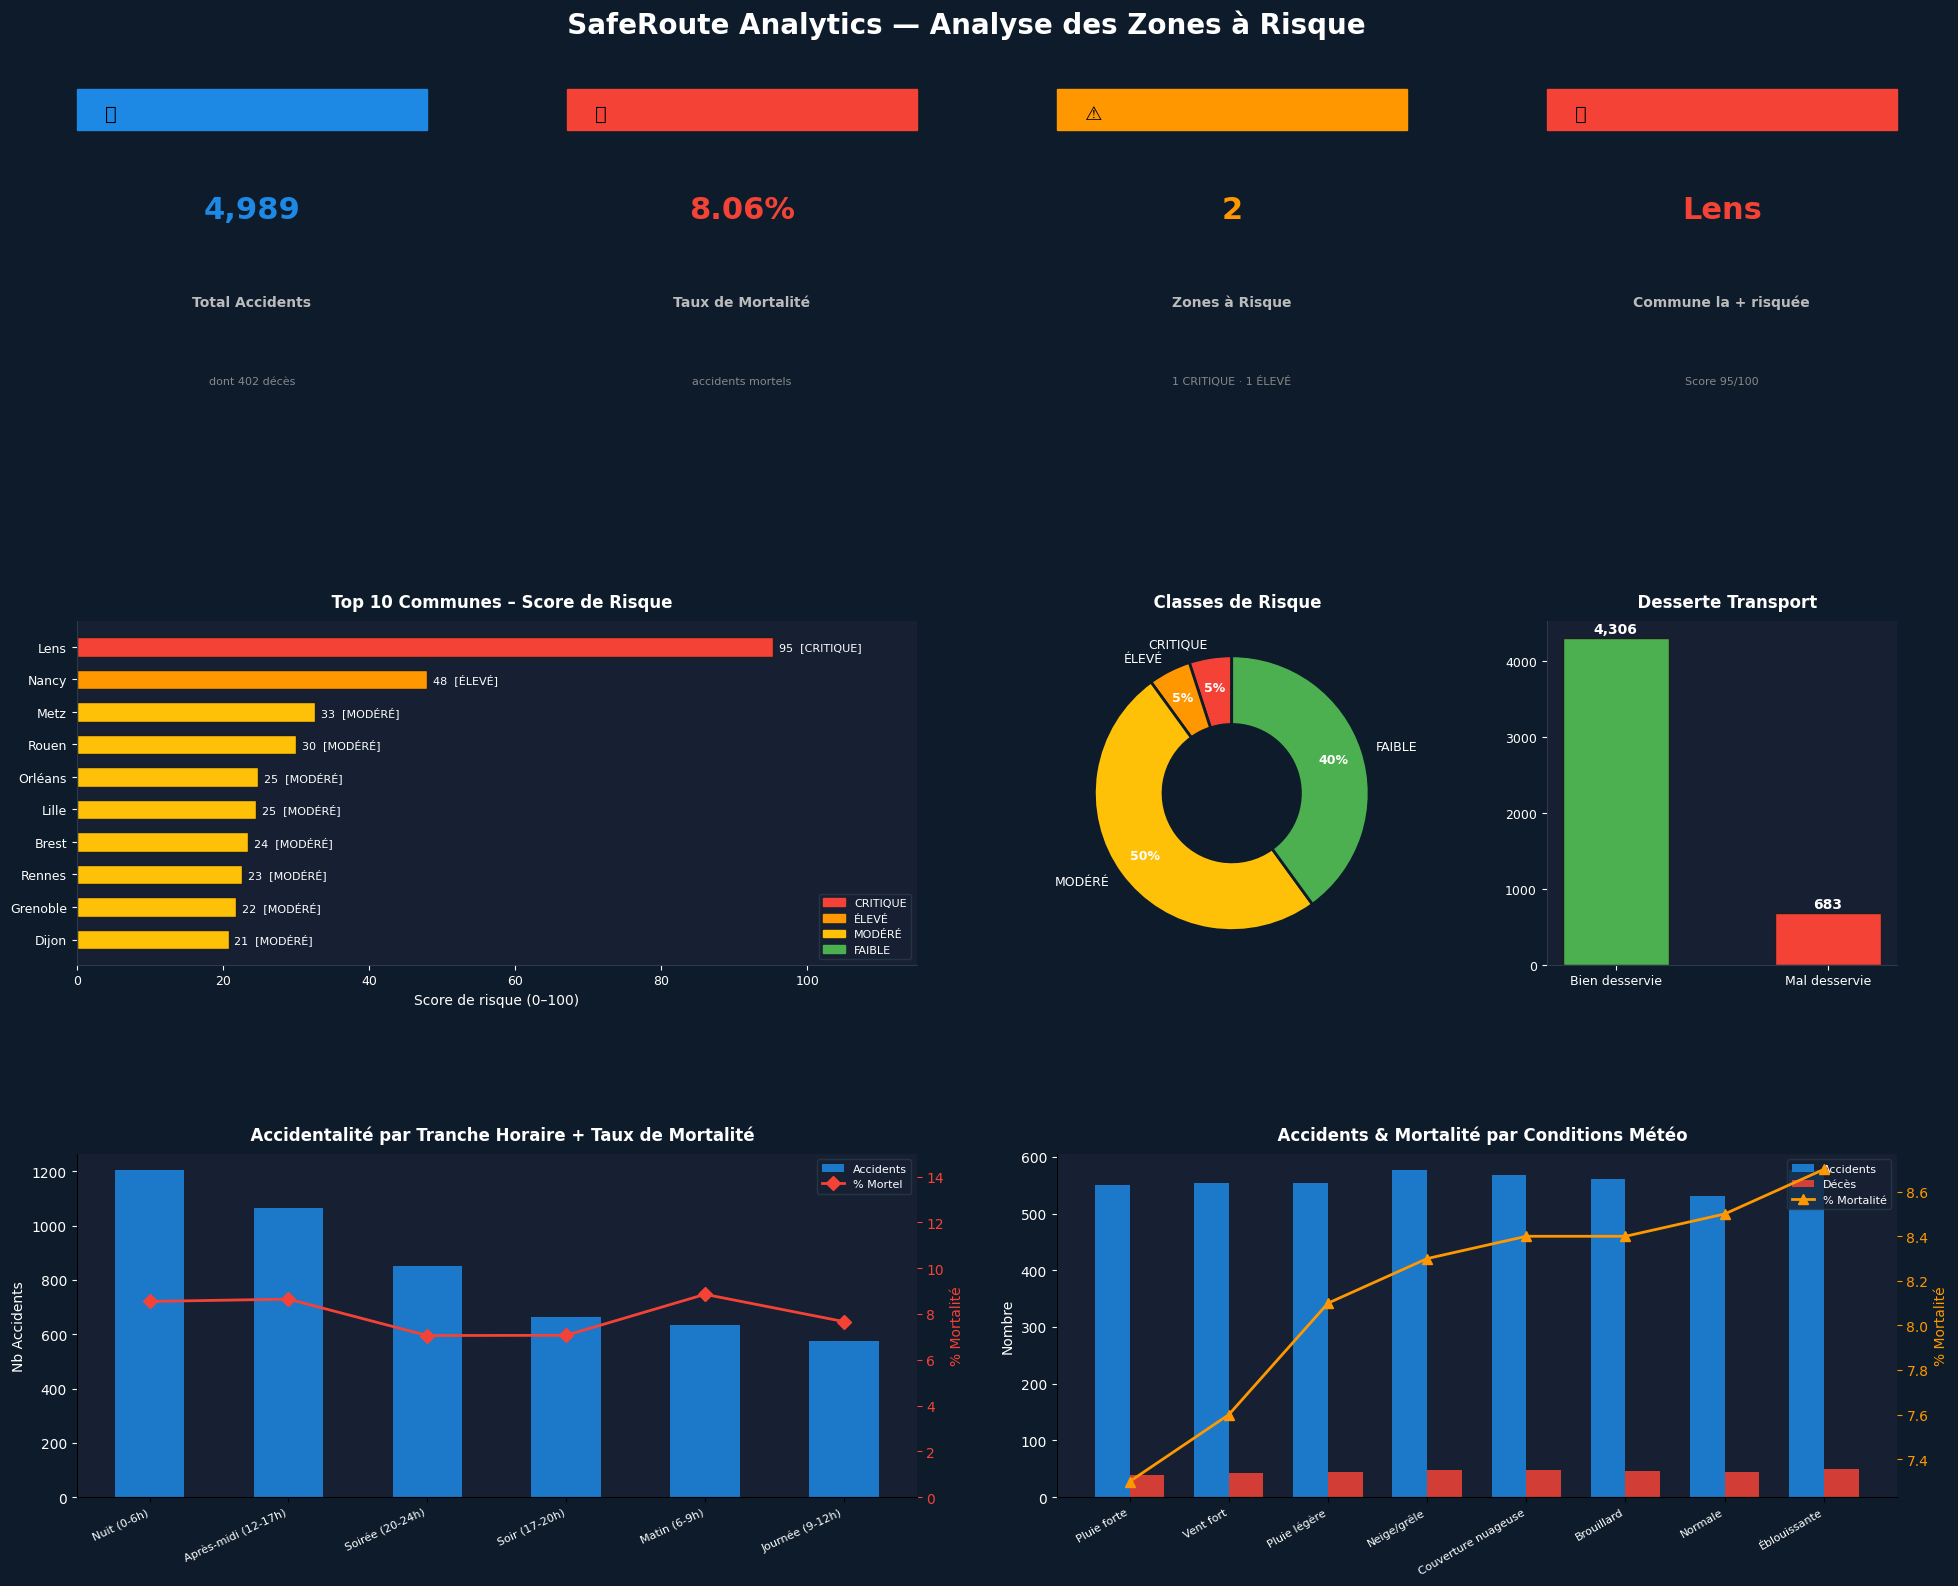

 Dashboard sauvegardé : saferoute_dashboard.png


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# VISUALISATION – Dashboard Zones à Risque avec KPI
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor("#0D1B2A")
fig.suptitle("  SafeRoute Analytics — Analyse des Zones à Risque",
             fontsize=20, fontweight="bold", color="white", y=0.99)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4,
                       top=0.94, bottom=0.06, left=0.06, right=0.97)

# ── Palette ───────────────────────────────────────────────────────────────────
C_CRITIQUE = "#F44336"
C_ELEVE    = "#FF9800"
C_MODERE   = "#FFC107"
C_FAIBLE   = "#4CAF50"
C_BLUE     = "#1E88E5"
C_BG       = "#0D1B2A"
C_PANEL    = "#162032"
C_TEXT     = "white"

color_risque = {"CRITIQUE": C_CRITIQUE, "ÉLEVÉ": C_ELEVE,
                "MODÉRÉ": C_MODERE, "FAIBLE": C_FAIBLE}

# ════════════════════════════════════════════════════════════════════════════
# LIGNE 1 – CARTES KPI (4 cartes)
# ════════════════════════════════════════════════════════════════════════════

# Calcul des KPI
total_accidents   = len(df_enrichi)
total_deces       = int(df_enrichi["est_mortel"].sum())
taux_mortalite    = round(total_deces / total_accidents * 100, 2)
zones_critiques   = int((agg_commune["classe_risque"] == "CRITIQUE").sum())
zones_elevees     = int((agg_commune["classe_risque"] == "ÉLEVÉ").sum())
zones_a_risque    = zones_critiques + zones_elevees
taux_qualite      = round(quality_report["accidents"]["taux_qualite"], 1)
commune_top       = agg_commune.nlargest(1, "score_risque").iloc[0]
score_max         = commune_top["score_risque"]
commune_top_nom   = commune_top["nom_commune"]
zones_mal_desserv = int(df_enrichi["zone_mal_desservie"].sum())

kpis = [
    {"label": "Total Accidents",     "value": f"{total_accidents:,}",
     "sous": f"dont {total_deces} décès",         "color": C_BLUE,     "icon": "🚗"},
    {"label": "Taux de Mortalité",   "value": f"{taux_mortalite}%",
     "sous": "accidents mortels",                  "color": C_CRITIQUE, "icon": "💀"},
    {"label": "Zones à Risque",      "value": f"{zones_a_risque}",
     "sous": f"{zones_critiques} CRITIQUE · {zones_elevees} ÉLEVÉ", "color": C_ELEVE, "icon": "⚠️"},
    {"label": "Commune la + risquée","value": commune_top_nom,
     "sous": f"Score {score_max:.0f}/100",         "color": C_CRITIQUE, "icon": "📍"},
]

for i, kpi in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(C_PANEL)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")
    # Barre couleur en haut
    ax.add_patch(mpatches.FancyBboxPatch((0, 0.88), 1, 0.12,
                 boxstyle="square,pad=0", color=kpi["color"], clip_on=False))
    ax.text(0.08, 0.93, kpi["icon"], fontsize=14, va="center", ha="left")
    ax.text(0.5, 0.65, kpi["value"], fontsize=22, fontweight="bold",
            color=kpi["color"], ha="center", va="center")
    ax.text(0.5, 0.38, kpi["label"], fontsize=10, color="#BBBBBB",
            ha="center", va="center", fontweight="bold")
    ax.text(0.5, 0.15, kpi["sous"],  fontsize=8,  color="#888888",
            ha="center", va="center")
    for spine in ax.spines.values():
        spine.set_edgecolor("#2A3A4A")
        spine.set_linewidth(1.5)

# ════════════════════════════════════════════════════════════════════════════
# LIGNE 2 – GRAPHIQUES ZONES À RISQUE
# ════════════════════════════════════════════════════════════════════════════

# ── 2A. TOP 10 COMMUNES – Score de risque (span 2 cols) ─────────────────────
ax_top = fig.add_subplot(gs[1, 0:2])
ax_top.set_facecolor(C_PANEL)
top10 = agg_commune.nlargest(10, "score_risque").sort_values("score_risque")
bar_colors = [color_risque.get(c, "#9E9E9E") for c in top10["classe_risque"]]
bars = ax_top.barh(top10["nom_commune"], top10["score_risque"],
                   color=bar_colors, height=0.6, edgecolor="#1E1E1E")
for bar, val, cls in zip(bars, top10["score_risque"], top10["classe_risque"]):
    ax_top.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
                f"{val:.0f}  [{cls}]", va="center", fontsize=8, color="white")
ax_top.set_facecolor(C_PANEL)
ax_top.tick_params(colors="white", labelsize=9)
ax_top.xaxis.label.set_color("white")
ax_top.set_xlabel("Score de risque (0–100)", color="white")
ax_top.set_title("  Top 10 Communes – Score de Risque", color="white",
                 fontsize=12, fontweight="bold", pad=10)
ax_top.set_xlim(0, 115)
ax_top.spines["bottom"].set_color("#2A3A4A")
ax_top.spines["left"].set_color("#2A3A4A")
patches_r = [mpatches.Patch(color=v, label=k) for k, v in color_risque.items()]
ax_top.legend(handles=patches_r, fontsize=8, loc="lower right",
              facecolor=C_PANEL, edgecolor="#2A3A4A", labelcolor="white")

# ── 2B. RÉPARTITION DES CLASSES DE RISQUE (donut) ───────────────────────────
ax_donut = fig.add_subplot(gs[1, 2])
ax_donut.set_facecolor(C_PANEL)
risque_counts = agg_commune["classe_risque"].value_counts()
order = ["CRITIQUE", "ÉLEVÉ", "MODÉRÉ", "FAIBLE"]
vals  = [risque_counts.get(k, 0) for k in order]
cols  = [color_risque[k] for k in order]
wedges, texts, autotexts = ax_donut.pie(
    vals, labels=order, colors=cols, autopct="%1.0f%%",
    startangle=90, pctdistance=0.78,
    wedgeprops={"width": 0.5, "edgecolor": C_BG, "linewidth": 2},
    textprops={"color": "white", "fontsize": 9}
)
for at in autotexts:
    at.set_fontweight("bold"); at.set_fontsize(9)
ax_donut.set_title("  Classes de Risque", color="white",
                   fontsize=12, fontweight="bold", pad=10)

# ── 2C. ZONES MAL DESSERVIES vs BIEN DESSERVIES ──────────────────────────────
ax_serv = fig.add_subplot(gs[1, 3])
ax_serv.set_facecolor(C_PANEL)
bien   = total_accidents - zones_mal_desserv
labels_s = ["Bien desservie", "Mal desservie"]
vals_s   = [bien, zones_mal_desserv]
colors_s = [C_FAIBLE, C_CRITIQUE]
bars_s = ax_serv.bar(labels_s, vals_s, color=colors_s, width=0.5,
                      edgecolor="#1E1E1E")
for bar, val in zip(bars_s, vals_s):
    ax_serv.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{val:,}", ha="center", va="bottom", color="white", fontsize=10,
                 fontweight="bold")
ax_serv.set_facecolor(C_PANEL)
ax_serv.tick_params(colors="white", labelsize=9)
ax_serv.yaxis.label.set_color("white")
ax_serv.set_title("  Desserte Transport", color="white",
                  fontsize=12, fontweight="bold", pad=10)
ax_serv.spines["bottom"].set_color("#2A3A4A")
ax_serv.spines["left"].set_color("#2A3A4A")

# ════════════════════════════════════════════════════════════════════════════
# LIGNE 3 – ANALYSE TEMPORELLE & MÉTÉO
# ════════════════════════════════════════════════════════════════════════════

# ── 3A. ACCIDENTS PAR TRANCHE HORAIRE + % MORTEL ─────────────────────────────
ax_h = fig.add_subplot(gs[2, 0:2])
ax_h.set_facecolor(C_PANEL)
horaire_s = agg_horaire.sort_values("nb_accidents", ascending=False)
x_h = np.arange(len(horaire_s))
bars_h = ax_h.bar(x_h, horaire_s["nb_accidents"], color=C_BLUE, alpha=0.85,
                   width=0.5, label="Accidents")
ax_h2 = ax_h.twinx()
ax_h2.plot(x_h, horaire_s["pct_mortel"], color=C_CRITIQUE, marker="D",
           linewidth=2, markersize=7, label="% Mortel")
ax_h2.set_ylim(0, 15)
ax_h2.tick_params(colors=C_CRITIQUE)
ax_h2.yaxis.label.set_color(C_CRITIQUE)
ax_h2.set_ylabel("% Mortalité", color=C_CRITIQUE)
ax_h2.spines["top"].set_visible(False)
ax_h2.spines["right"].set_color("#2A3A4A")
ax_h.set_xticks(x_h)
ax_h.set_xticklabels(horaire_s["tranche_horaire"].astype(str),
                      rotation=25, ha="right", fontsize=8, color="white")
ax_h.tick_params(axis="y", colors="white")
ax_h.set_ylabel("Nb Accidents", color="white")
ax_h.set_title("  Accidentalité par Tranche Horaire + Taux de Mortalité",
               color="white", fontsize=12, fontweight="bold", pad=10)
ax_h.spines["bottom"].set_color("#2A3A4A")
ax_h.spines["left"].set_color("#2A3A4A")
lines1, labels1 = ax_h.get_legend_handles_labels()
lines2, labels2 = ax_h2.get_legend_handles_labels()
ax_h.legend(lines1+lines2, labels1+labels2, fontsize=8, facecolor=C_PANEL,
            edgecolor="#2A3A4A", labelcolor="white", loc="upper right")

# ── 3B. TAUX MORTALITÉ PAR CONDITIONS MÉTÉO (radar/bar) ──────────────────────
ax_m = fig.add_subplot(gs[2, 2:4])
ax_m.set_facecolor(C_PANEL)
meteo_s = agg_meteo.copy()
meteo_s["taux_mortel"] = (meteo_s["nb_mortels"] / meteo_s["nb_accidents"] * 100).round(1)
meteo_s = meteo_s.sort_values("taux_mortel", ascending=True).tail(8)
x_m = np.arange(len(meteo_s))
w = 0.35
b1 = ax_m.bar(x_m - w/2, meteo_s["nb_accidents"], w, label="Accidents",
              color=C_BLUE, alpha=0.85)
b2 = ax_m.bar(x_m + w/2, meteo_s["nb_mortels"], w, label="Décès",
              color=C_CRITIQUE, alpha=0.85)
ax_m2 = ax_m.twinx()
ax_m2.plot(x_m, meteo_s["taux_mortel"], color=C_ELEVE, marker="^",
           linewidth=2, markersize=7, label="% Mortalité")
ax_m2.set_ylabel("% Mortalité", color=C_ELEVE)
ax_m2.tick_params(colors=C_ELEVE)
ax_m2.spines["top"].set_visible(False)
ax_m2.spines["right"].set_color("#2A3A4A")
ax_m.set_xticks(x_m)
ax_m.set_xticklabels(meteo_s["conditions_meteo"], rotation=30, ha="right",
                      fontsize=8, color="white")
ax_m.tick_params(axis="y", colors="white")
ax_m.set_ylabel("Nombre", color="white")
ax_m.set_title("  Accidents & Mortalité par Conditions Météo",
               color="white", fontsize=12, fontweight="bold", pad=10)
ax_m.spines["bottom"].set_color("#2A3A4A")
ax_m.spines["left"].set_color("#2A3A4A")
lines_m = ax_m.get_legend_handles_labels()
lines_m2 = ax_m2.get_legend_handles_labels()
ax_m.legend(lines_m[0]+lines_m2[0], lines_m[1]+lines_m2[1], fontsize=8,
            facecolor=C_PANEL, edgecolor="#2A3A4A", labelcolor="white")

# ── Sauvegarde ────────────────────────────────────────────────────────────────
plt.savefig("saferoute_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=C_BG, edgecolor="none")
plt.show()
print(" Dashboard sauvegardé : saferoute_dashboard.png")
